<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/fastai2_unet_solution_camvid_normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## installs fastai v2 (Google Colab comes with fastai v1 by default)
# this will also ask permision to access your Google Drive
!pip install -q fastbook==0.0.29
import fastbook
fastbook.setup_book()

In [ ]:
#camvid_path  = untar_data(URLs.CAMVID)
#camvid_tiny_path  = untar_data(URLs.CAMVID_TINY)

In [ ]:
# the variable gdrive now contains you Google Drive path
# this is a pathlib Path object
# we can create new file paths from it using the '/' operator
# See: https://realpython.com/python-pathlib/
from fastbook import *
gdrive

Path('/content/gdrive/My Drive')

In [ ]:
# See: https://www.geeksforgeeks.org/python-os-path-exists-method/
if not (gdrive / 'camvid_normal').is_dir():
  # https://www.geeksforgeeks.org/python-os-mkdir-method/
  os.mkdir(gdrive / 'camvid_normal')
  path = untar_data(URLs.CAMVID, data = gdrive / 'camvid_normal')

In [ ]:
URLs

In [ ]:
path = path / 'camvid'

In [ ]:
import os
os.listdir(path)

['labels', 'codes.txt', 'images', 'valid.txt']

In [ ]:
# codes.txt contains the label code for our pixels
# class 0 is Animal, class 1 is Archway
# class 2 is Bicyclist, etc.
codes = np.loadtxt(path / 'codes.txt', dtype=str)
codes

array(['Animal', 'Archway', 'Bicyclist', 'Bridge', 'Building', 'Car', 'CartLuggagePram', 'Child', 'Column_Pole', 'Fence', 'LaneMkgsDriv', 'LaneMkgsNonDriv', 'Misc_Text', 'MotorcycleScooter',
       'OtherMoving', 'ParkingBlock', 'Pedestrian', 'Road', 'RoadShoulder', 'Sidewalk', 'SignSymbol', 'Sky', 'SUVPickupTruck', 'TrafficCone', 'TrafficLight', 'Train', 'Tree', 'Truck_Bus', 'Tunnel',
       'VegetationMisc', 'Void', 'Wall'], dtype='<U17')

/content/gdrive/My Drive/camvid_normal/camvid/images/Seq05VD_f00630.png


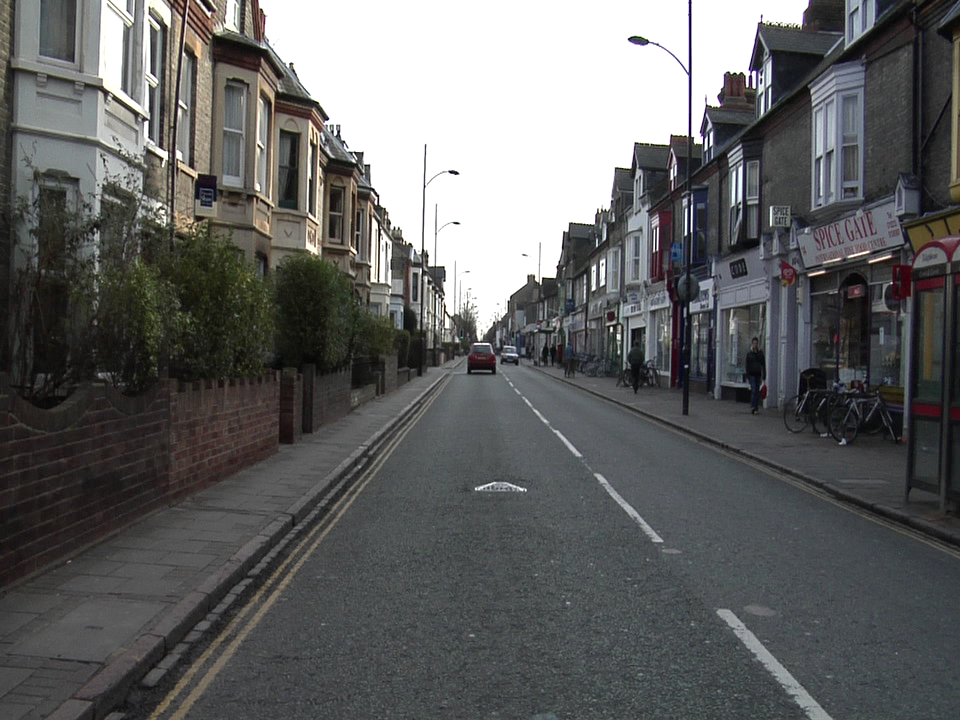

In [ ]:
from PIL import Image
unlabeled_images = os.listdir(path / 'images')
print(path / 'images' / unlabeled_images[0])
image = Image.open(path / 'images' / unlabeled_images[0])
image

(720, 960, 3)


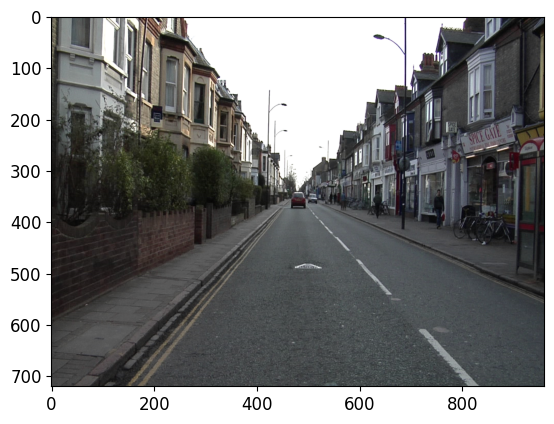

In [ ]:
import matplotlib.pyplot as plt
# let's see its dimensions
pix = np.array(image)
print(pix.shape)
plt.imshow(pix);

In [ ]:
# check out what Path.stem and Path.suffix give us
Path(unlabeled_images[0]).stem, Path(unlabeled_images[0]).suffix

('Seq05VD_f00630', '.png')

In [ ]:
# in the labels folder we have a 0016E5_08370_P.png file with a label for every pixel in the image
label_file_path = f'{Path(unlabeled_images[0]).stem}_P{Path(unlabeled_images[0]).suffix}'
label_file_path

'Seq05VD_f00630_P.png'

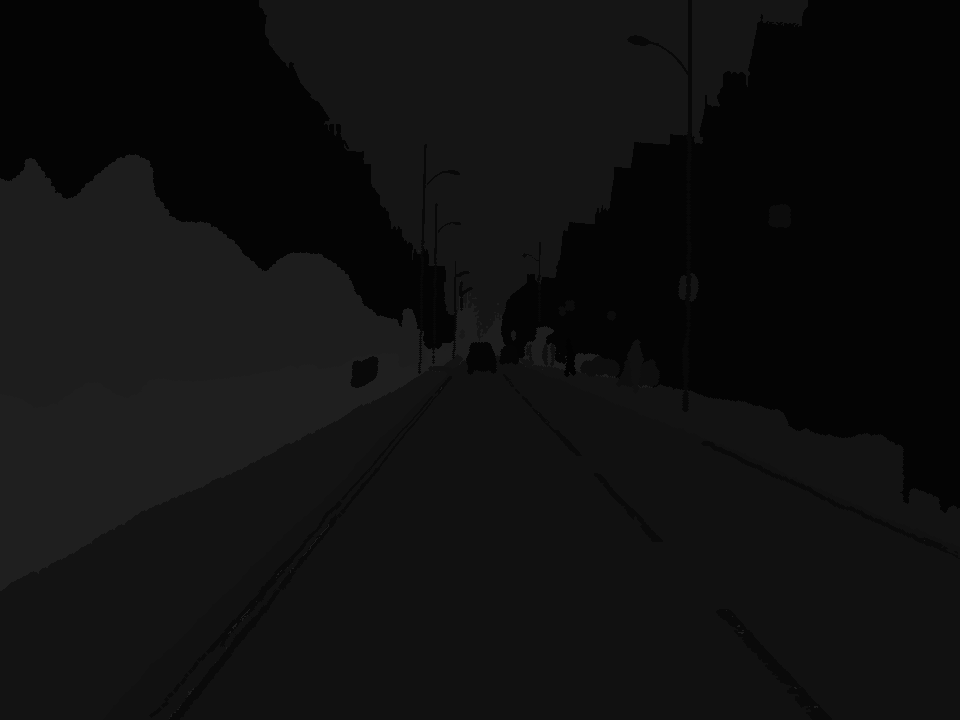

In [ ]:
# it's a gray scale image
label = Image.open(path / 'labels' / label_file_path)
label

2 31


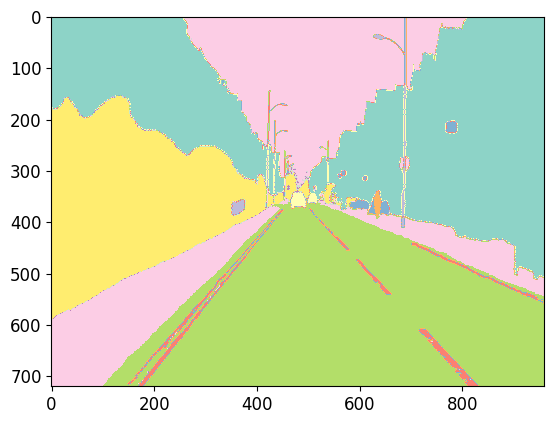

In [ ]:
# matplotlib allows to view it with a colormap
import numpy as np
label_array = np.array(label)
print(label_array.min(), label_array.max())
plt.imshow(label_array, cmap='Set3');

In [ ]:
# get the path of the matching image
# getting the label names for all files
label_names = [path/'labels'/f'{Path(o).stem}_P{Path(o).suffix}'  for o in unlabeled_images]
label_names[0:10]

[Path('/content/gdrive/My Drive/camvid_normal/camvid/labels/Seq05VD_f00630_P.png'),
 Path('/content/gdrive/My Drive/camvid_normal/camvid/labels/0006R0_f02940_P.png'),
 Path('/content/gdrive/My Drive/camvid_normal/camvid/labels/0006R0_f02700_P.png'),
 Path('/content/gdrive/My Drive/camvid_normal/camvid/labels/0016E5_08019_P.png'),
 Path('/content/gdrive/My Drive/camvid_normal/camvid/labels/0001TP_008970_P.png'),
 Path('/content/gdrive/My Drive/camvid_normal/camvid/labels/0001TP_007350_P.png'),
 Path('/content/gdrive/My Drive/camvid_normal/camvid/labels/0006R0_f01110_P.png'),
 Path('/content/gdrive/My Drive/camvid_normal/camvid/labels/0006R0_f01740_P.png'),
 Path('/content/gdrive/My Drive/camvid_normal/camvid/labels/0016E5_07977_P.png'),
 Path('/content/gdrive/My Drive/camvid_normal/camvid/labels/0016E5_08097_P.png')]

In [ ]:
# turn it into a labeling function
def label_func(x):
  return path/'labels'/f'{x.stem}_P{x.suffix}'


In [ ]:
# https://docs.fast.ai/vision.data.html#SegmentationDataLoaders
set_seed(42)
dls = SegmentationDataLoaders.from_label_func(
    path,
    # note that I use a smaller batch size when dealing with bigger images
    bs=1,
    fnames = get_image_files(path/"images"),
    label_func = label_func,
    codes = np.loadtxt(path/'codes.txt', dtype=str)
)

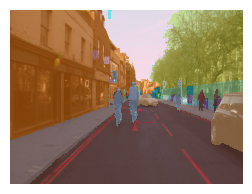

In [ ]:
# show a batch of data, the masks will be overlayed on the images
dls.show_batch()

In [ ]:
# we get a batch of data as training tensor images and training tensor labels using one_batch()
x, y = dls.one_batch()
# the labels are now images with the same dimensions as the input
# labels are encoded as integers
x.shape, y.shape

(torch.Size([1, 3, 720, 960]), torch.Size([1, 720, 960]))

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
import gc
gc.collect()

15736

In [ ]:
# we create a unet_learner with a resnet18 backbone

learn = unet_learner(dls, resnet18, pretrained=True)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


SuggestedLRs(valley=0.00010964782268274575)

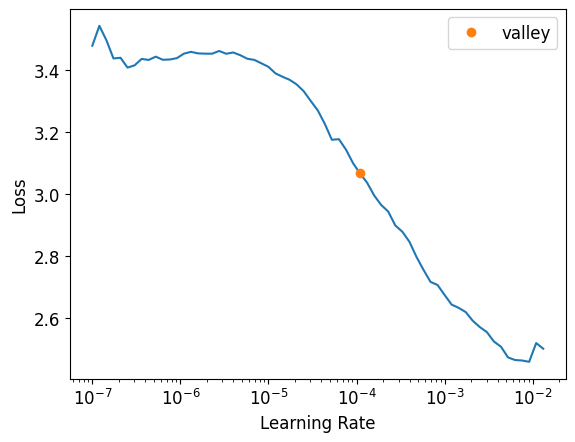

In [ ]:
# find a "good" learning rate
lrs = learn.lr_find()
lrs

In [ ]:
dir(lrs)

['__add__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getnewargs__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmul__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '_asdict',
 '_field_defaults',
 '_fields',
 '_make',
 '_replace',
 'count',
 'index',
 'valley']

In [ ]:
# fine tune for only two epochs
learn.fine_tune(2, base_lr=lrs.valley)

epoch,train_loss,valid_loss,time
0,0.790098,0.661887,01:09


epoch,train_loss,valid_loss,time
0,0.499310,0.563685,01:10
1,0.378954,0.456456,01:10


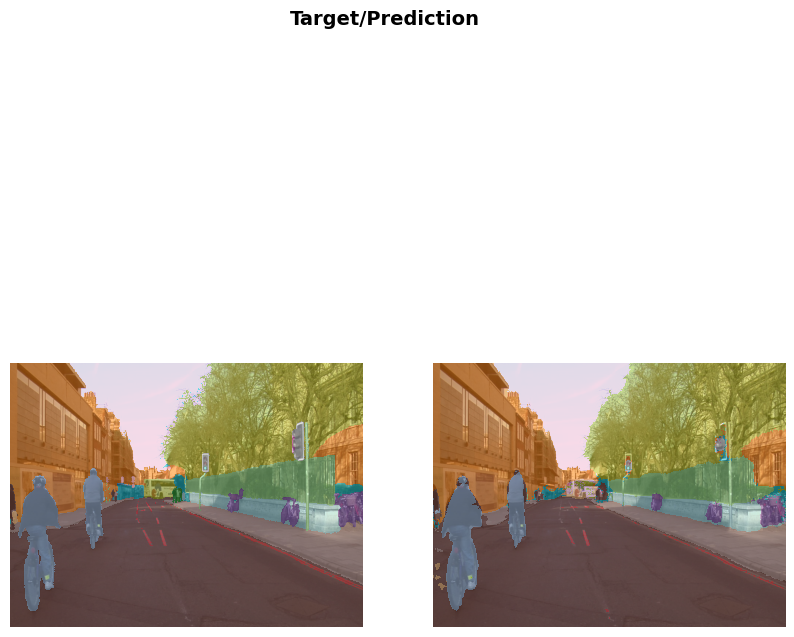

In [ ]:
# see results
learn.show_results(max_n=3, figsize=(10, 10))

In [ ]:
# train for six more epochs
learn.fine_tune(6, base_lr=lrs.valley)

epoch,train_loss,valid_loss,time
0,0.494146,0.534490,01:09


epoch,train_loss,valid_loss,time
0,0.350946,0.441579,01:10
1,0.318390,0.454820,01:10
2,0.273901,0.471652,01:10
3,0.204930,0.429171,01:10
4,0.184827,0.430301,01:10
5,0.166004,0.432198,01:10


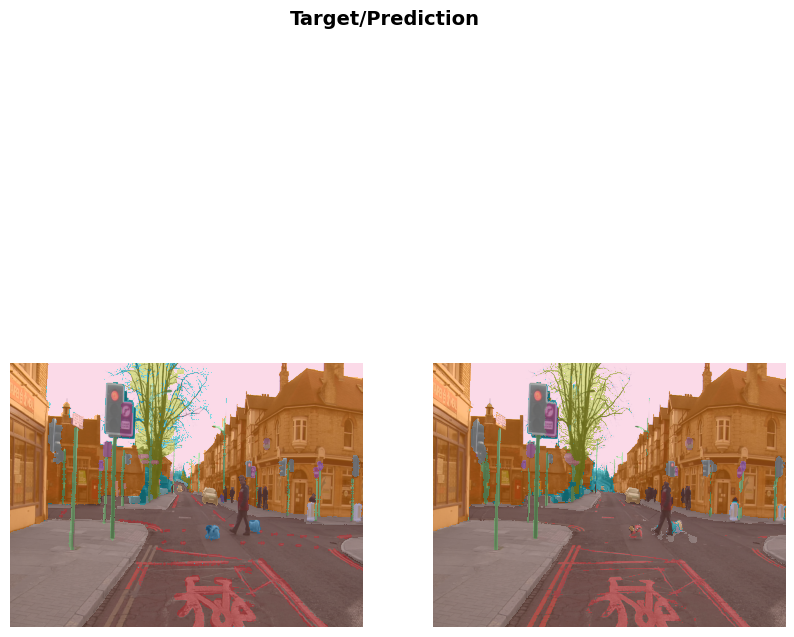

In [ ]:
# see results again
learn.show_results(max_n=3, figsize=(10, 10))

In [ ]:
# train for 10 more epochs, use default learning rate
learn.fine_tune(10)


epoch,train_loss,valid_loss,time
0,0.852880,0.768238,01:09


epoch,train_loss,valid_loss,time
0,0.416700,0.574881,01:10
1,0.412916,0.469032,01:10
2,0.420009,0.511195,01:10
3,0.396152,0.408156,01:10
4,0.262505,0.392756,01:10
5,0.246517,0.358582,01:10
6,0.186411,0.336239,01:10
7,0.147655,0.348346,01:10
8,0.140979,0.336592,01:10
9,0.132146,0.335756,01:10


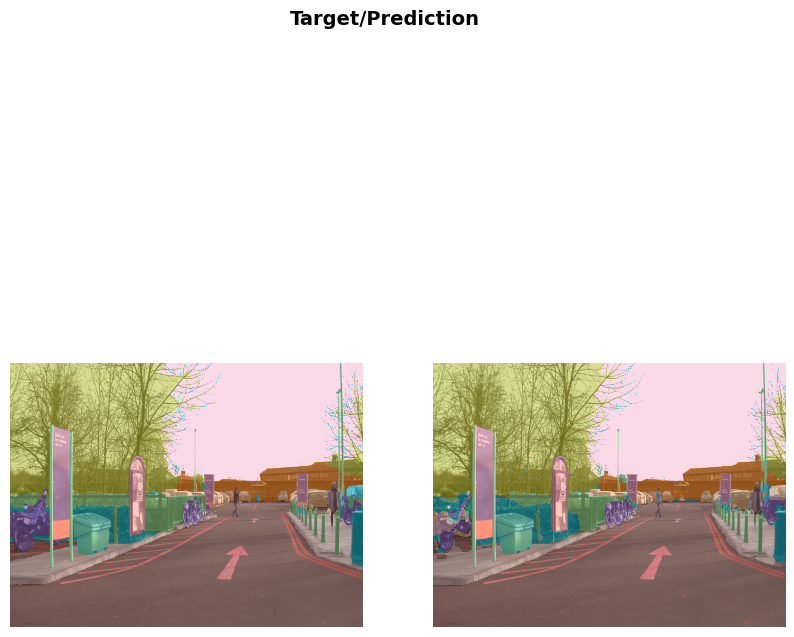

In [ ]:
# results will be ok for many applications (e.g. road or sky segmentation)
# but not particularly impressive for small blobs/objects
# don't use this to detect cars/pedestrians!
learn.show_results(max_n=3, figsize=(10, 10))

In [ ]:
learn.export(path / 'trained_unet.pkl')